# LABP-KS: kernel sensing, angular asymmetry, and MIPS sanity checks

Compare **no sensing**, **symmetric perpendicular sensing** (\(\chi=0\)), and **cyclic perpendicular sensing** (\(\chi=1\)) at identical baseline rates and shell gains. The four direction labels are up, right, down, left. A particle in direction \(c_i\) senses
\[
q_{i,k}=\frac{1+\chi}{2}N_{i,k}^{c_i+1}+\frac{1-\chi}{2}N_{i,k}^{c_i-1},\qquad
G_{i,k}=\beta_k[1-e^{-q_{i,k}/n_*}],\qquad
w_{i,+}=w_-+(w_+^0-w_-)e^{\sum_kG_{i,k}}.
\]
\(N_{i,k}^{d}\) counts direction-\(d\) neighbors over the full exclusive Chebyshev shell; all positions on that shell have equal spatial weight. Only forward propulsion increases. Backward, lateral, and rotation rates stay fixed, and occupied destinations block hops.

The simulator executes exact individual Gillespie events. CPU workers or bounded CUDA batches process independent replicas, each with its own clock. Frames are recorded at **fixed physical times** \(t_j=t_{\rm burn}+j\,\texttt{SAMPLE_DT}\); this is output sampling, not an integration step. `LABPKS_BACKEND=auto|cpu|cuda` chooses the backend, `LABPKS_CUDA_BATCH_SIZE` caps CUDA replicas per batch, and `LABPKS_WORKERS` controls CPU threads. Explicit CUDA requests fail if unavailable.

The notebook checks density fields, independent-replica clusters, density distributions, Fourier structure factors, sensing statistics, and complete inter-event waiting times. Defaults are a screening experiment at low density, not a known MIPS coexistence point. Large clusters alone do not prove MIPS. Compare sizes, densities, run lengths and seeds before making that claim.

Angular bias changes reciprocity **and** the distribution of the weighted sensing count, despite a fixed sum of angular weights. Inspect the sensing and speed statistics when interpreting differences. Mirroring the geometry maps `chi` to `-chi`; scalar entropy production or a radial learned spectrum need not reverse sign. Symmetric sensing remains an active model.

Set `LABPKS_SMOKE=1` for a small execution check. Run all cells in order.


In [31]:
import os
import sys
import json
import math
import hashlib
from pathlib import Path
from datetime import datetime, timezone
from dataclasses import asdict, replace

ROOT = Path("/home/ldh041203/projects/CNEEP_v2")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap
from IPython.display import HTML, display
from tqdm.auto import tqdm
from data.labp_ks import LABPKSConfig, simulate_ensemble, simulation_backend
from data.lattice_abp.mips_analysis import (
    coarse_density_periodic, summarize_mips_snapshot,
)

SMOKE = os.environ.get("LABPKS_SMOKE", "0") == "1"
print("Project:", ROOT, "| smoke:", SMOKE)


Project: /home/ldh041203/projects/CNEEP_v2 | smoke: False


## Parameters and fixed sampling interval

- `SAMPLE_DT`: physical time between saved frames; sampling frequency is its reciprocal.
- `OBSERVATION_TIME`: duration **after** burn-in; frame count is derived from these two controls.
- `BURN_TIME=0` starts from a random configuration so cluster formation is visible. For a stationary-state check, increase it and inspect whether diagnostics stop drifting.
- `rotation_rate` is the rate of each of the two 90-degree turns; orientation correlation decays as \(\exp(-2\gamma t)\).
- `COARSE_BOX` controls density smoothing. Compare several values; overlapping windows do not provide independent samples.
- Independent replicas determine error bars. All model variants start from identical random initial configurations for a paired comparison, with independent replicas within each variant.


In [32]:
physics = LABPKSConfig(
    lattice_size=10 if SMOKE else 30,
    density=0.3,
    forward_rate=10,
    backward_rate=1,
    lateral_rate=1,
    rotation_rate=0.1,
    shell_weights=(0.0, 1.0, 0.0),  # beta_2, beta_3, beta_4; active k=3
    sensing_scale=1.0,
    angular_bias=1.0,
)
ENSEMBLE_SIZE = 2 if SMOKE else 4
SAMPLE_DT = 0.05 if SMOKE else 1.0
OBSERVATION_TIME = 0.5 if SMOKE else 10000.0
BURN_TIME = 0.0
SIMULATION_BACKEND = os.environ.get("LABPKS_BACKEND", "auto").strip().lower()
RESOLVED_SIMULATION_BACKEND = simulation_backend(SIMULATION_BACKEND)
CUDA_BATCH_SIZE = int(os.environ.get("LABPKS_CUDA_BATCH_SIZE", "64"))
WORKERS = int(os.environ["LABPKS_WORKERS"]) if "LABPKS_WORKERS" in os.environ else None  # None uses available CPUs
SEED = 17031
COARSE_BOX = 3 if SMOKE else 6
DIAGNOSTIC_STRIDE = 1 if SMOKE else 5
LATE_FRACTION = 0.5
RANDOM_REFERENCE_SAMPLES = 8 if SMOKE else 64
SHOW_ANIMATION = not SMOKE
MAX_ANIMATION_FRAMES = 80
SAVE_TRAJECTORIES = False

if not (math.isfinite(SAMPLE_DT) and SAMPLE_DT > 0
        and math.isfinite(OBSERVATION_TIME) and OBSERVATION_TIME > 0):
    raise ValueError("SAMPLE_DT and OBSERVATION_TIME must be finite and positive.")
intervals = int(round(OBSERVATION_TIME / SAMPLE_DT))
if intervals < 2 or not math.isclose(intervals * SAMPLE_DT, OBSERVATION_TIME,
                                   rel_tol=1e-10, abs_tol=1e-12):
    raise ValueError("OBSERVATION_TIME must be an integer multiple of SAMPLE_DT, with at least two intervals.")
if ENSEMBLE_SIZE < 2:
    raise ValueError("Use at least two independent replicas for ensemble error bars.")
if not 1 <= COARSE_BOX < physics.lattice_size:
    raise ValueError("COARSE_BOX must be between 1 and lattice_size-1.")
if not 0 < LATE_FRACTION <= 1 or DIAGNOSTIC_STRIDE < 1:
    raise ValueError("Use 0 < LATE_FRACTION <= 1 and DIAGNOSTIC_STRIDE >= 1.")
N_FRAMES = intervals + 1
cases = {
    "no_sensing": replace(physics, shell_weights=tuple(0.0 for _ in physics.shell_weights)),
    "symmetric_sensing": replace(physics, angular_bias=0.0),
    "cyclic_sensing": physics,
}
OUTPUT_BASE = Path(os.environ.get("LABPKS_OUTPUT_DIR", str(ROOT / "results"))).expanduser()
RESULT_DIR = OUTPUT_BASE / "labpks_mips" / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
RESULT_DIR.mkdir(parents=True, exist_ok=True)
print(json.dumps(asdict(physics), indent=2))
print(f"Simulation backend: {RESOLVED_SIMULATION_BACKEND} (requested {SIMULATION_BACKEND})")
print(f"CPU workers={WORKERS if WORKERS is not None else 'auto'}; CUDA replica batch size={CUDA_BATCH_SIZE}")
print(f"{ENSEMBLE_SIZE} replicas/case; {N_FRAMES} frames; fixed dt={SAMPLE_DT:g}; frequency={1/SAMPLE_DT:g}")
print("Output:", RESULT_DIR)


{
  "lattice_size": 30,
  "density": 0.3,
  "forward_rate": 10.0,
  "backward_rate": 1.0,
  "lateral_rate": 1.0,
  "rotation_rate": 0.1,
  "shell_weights": [
    0.0,
    1.0,
    0.0
  ],
  "sensing_scale": 1.0,
  "angular_bias": 1.0
}
Simulation backend: cpu (requested auto)
CPU workers=auto; CUDA replica batch size=64
4 replicas/case; 10001 frames; fixed dt=1; frequency=1
Output: /home/ldh041203/projects/CNEEP_v2/results/labpks_mips/20260922T105745_926904Z


In [33]:
results = {}
for name, config in cases.items():
    print("Simulating:", name)
    result = simulate_ensemble(
        config, n_trajectories=ENSEMBLE_SIZE, n_frames=N_FRAMES,
        sample_dt=SAMPLE_DT, burn_time=BURN_TIME,
        seed=SEED, workers=WORKERS, progress=not SMOKE,
        backend=RESOLVED_SIMULATION_BACKEND, batch_size=CUDA_BATCH_SIZE,
    )
    np.testing.assert_allclose(np.diff(result.times), SAMPLE_DT, rtol=1e-10, atol=1e-12)
    np.testing.assert_allclose(result.times[-1], OBSERVATION_TIME)
    counts = (result.states >= 0).sum(axis=(-2, -1))
    np.testing.assert_array_equal(counts, config.n_particles)
    np.testing.assert_allclose(result.medium_ep_maps.sum(axis=(-2, -1)), result.medium_ep)
    results[name] = result
    if SAVE_TRAJECTORIES:
        np.savez_compressed(RESULT_DIR / f"{name}_trajectories.npz",
                            **vars(result), physics_json=np.asarray(json.dumps(asdict(config))))
if BURN_TIME == 0:
    for name, result in results.items():
        np.testing.assert_array_equal(results["no_sensing"].states[:, 0], result.states[:, 0])
times = results["cyclic_sensing"].times
diagnostic_frames = np.unique(np.r_[np.arange(0, N_FRAMES, DIAGNOSTIC_STRIDE), N_FRAMES - 1])
late_frames = diagnostic_frames[
    diagnostic_frames >= int(np.floor((1 - LATE_FRACTION) * (N_FRAMES - 1)))
]
print("Diagnostic frames:", len(diagnostic_frames), "| late frames:", len(late_frames))


Simulating: no_sensing


LABP-KS Gillespie replicas: 100%|████████████████████████████████████████████████████████| 4/4 [01:40<00:00, 25.12s/it]


Simulating: symmetric_sensing


LABP-KS Gillespie replicas: 100%|████████████████████████████████████████████████████████| 4/4 [01:39<00:00, 24.76s/it]


Simulating: cyclic_sensing


LABP-KS Gillespie replicas: 100%|████████████████████████████████████████████████████████| 4/4 [01:38<00:00, 24.67s/it]

Diagnostic frames: 2001 | late frames: 1001


## Density snapshots

The same replica is shown at three physical times. Density maps use one color scale across models. A dense domain separated from a dilute region, persisting across late frames and replicas, is stronger evidence than a single large connected cluster.

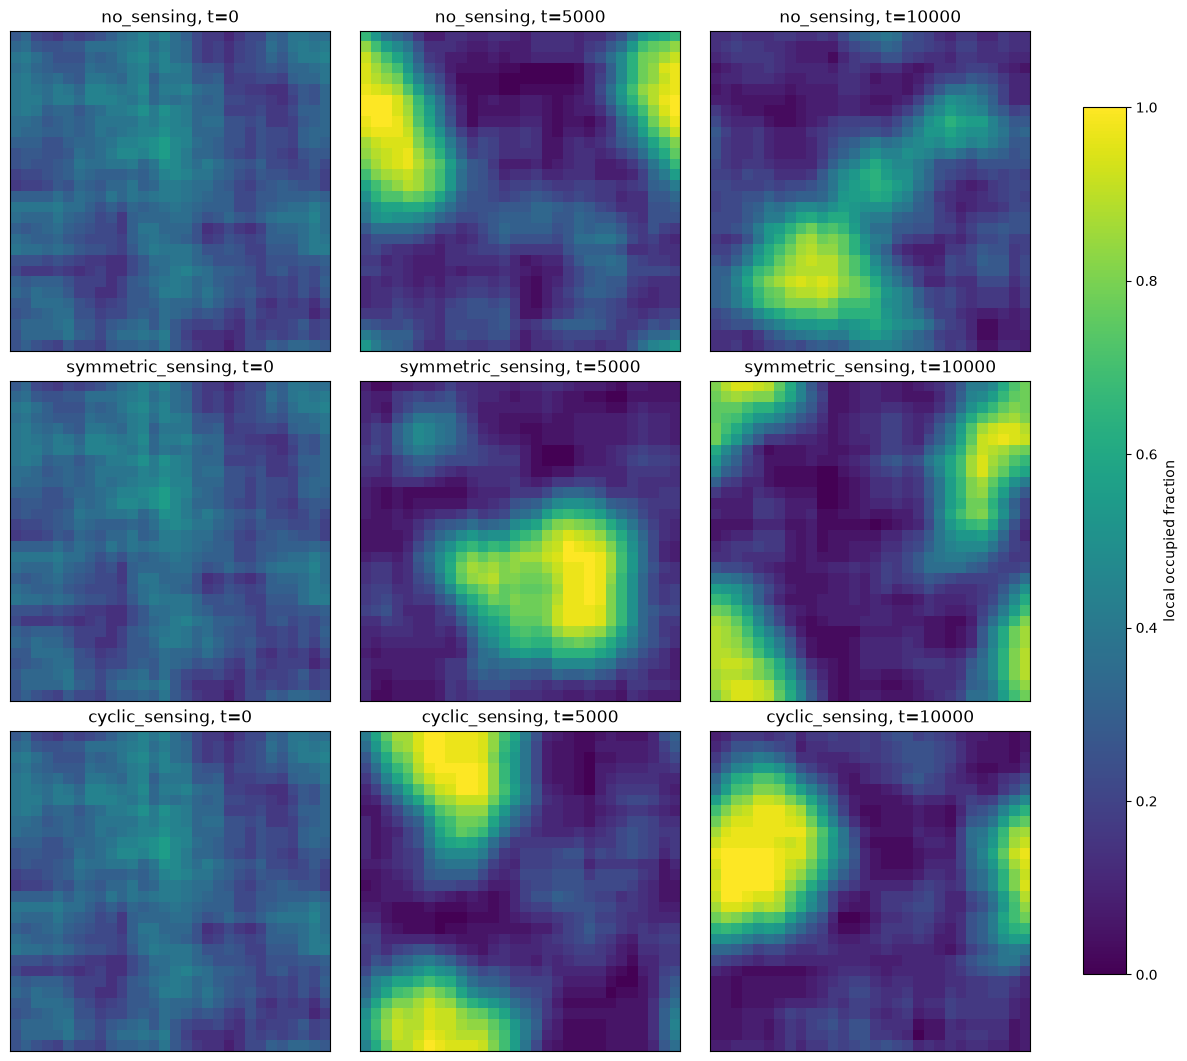

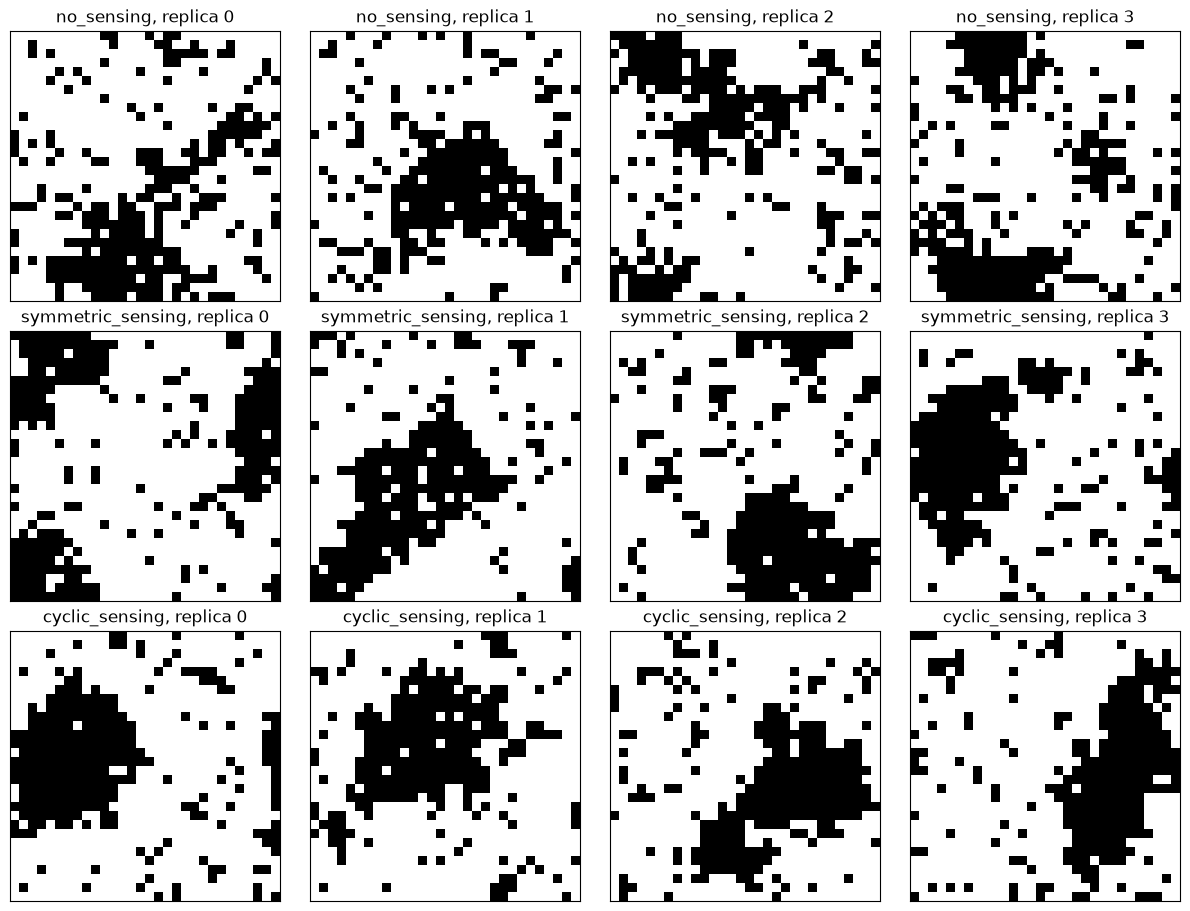

In [34]:
snapshot_frames = (0, N_FRAMES // 2, N_FRAMES - 1)
fig, axes = plt.subplots(len(results), 3, figsize=(12, 3.5 * len(results)), squeeze=False, constrained_layout=True)
for row, (name, result) in enumerate(results.items()):
    for col, frame in enumerate(snapshot_frames):
        density_field = coarse_density_periodic(result.states[0, frame] >= 0, box=COARSE_BOX)
        im = axes[row, col].imshow(density_field, origin="upper", cmap="viridis", vmin=0, vmax=1)
        axes[row, col].set_title(f"{name}, t={times[frame]:g}")
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
fig.colorbar(im, ax=axes.ravel().tolist(), label="local occupied fraction", shrink=0.85)
fig.savefig(RESULT_DIR / "density_snapshots.png", dpi=160)
plt.show()

# Inspect the final state of every independent replica, not only replica zero.
fig, axes = plt.subplots(len(results), ENSEMBLE_SIZE, figsize=(3 * ENSEMBLE_SIZE, 3 * len(results)), squeeze=False, constrained_layout=True)
for row, (name, result) in enumerate(results.items()):
    for replica in range(ENSEMBLE_SIZE):
        im = axes[row, replica].imshow(result.states[replica, -1] >= 0, cmap="Greys", vmin=0, vmax=1)
        axes[row, replica].set_title(f"{name}, replica {replica}")
        axes[row, replica].set_xticks([]); axes[row, replica].set_yticks([])
fig.savefig(RESULT_DIR / "all_replica_final_occupancy.png", dpi=160)
plt.show()


## Cluster size, density contrast, and low-q enhancement

Clusters use four-neighbor connectivity with periodic boundaries. The largest-cluster fraction is \(N_{\max}/N\); high density can yield a spanning cluster without phase separation.

The density contrast is the difference between the 90th and 10th percentiles of the local-density field. The low-q ratio compares mean Fourier power in \(0<|q|/(2\pi)\le0.12\) against \(0.12<|q|/(2\pi)\le0.35\).

Shaded bands are standard errors **across independent replicas**. The dotted references below come from random configurations with exactly the same lattice size and number of particles, accounting for finite-density connectivity.

diagnostics: cyclic_sensing: 100%|███████████████████████████████████████████████████████| 4/4 [00:05<00:00,  1.28s/it]


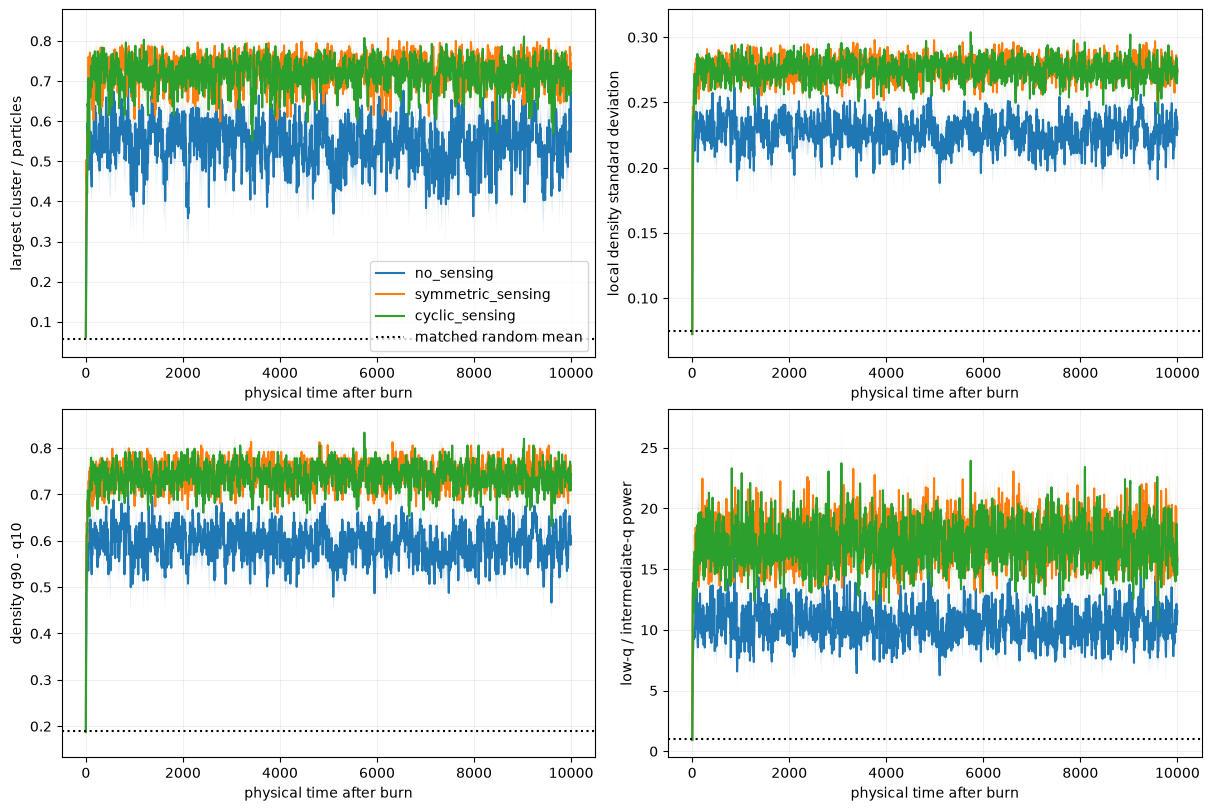

In [35]:
metric_keys = ("largest_cluster_fraction", "coarse_std", "density_contrast", "low_k_ratio")

def snapshot_metrics(occupied):
    values = summarize_mips_snapshot(occupied, coarse_box=COARSE_BOX, periodic=True)
    return np.array([values["largest_cluster_fraction"], values["coarse_std"],
                     values["coarse_q90"] - values["coarse_q10"], values["low_k_ratio"]])

def random_occupancy(rng):
    occupied = np.zeros(physics.lattice_size**2, dtype=bool)
    occupied[rng.choice(occupied.size, physics.n_particles, replace=False)] = True
    return occupied.reshape(physics.lattice_size, physics.lattice_size)

diagnostics = {}
for name, result in results.items():
    metrics = np.empty((ENSEMBLE_SIZE, len(diagnostic_frames), len(metric_keys)))
    for replica in tqdm(range(ENSEMBLE_SIZE), desc=f"diagnostics: {name}", disable=SMOKE):
        for index, frame in enumerate(diagnostic_frames):
            metrics[replica, index] = snapshot_metrics(result.states[replica, frame] >= 0)
    assert np.isfinite(metrics).all()
    diagnostics[name] = metrics
rng = np.random.default_rng(SEED + 991)
random_states = np.stack([random_occupancy(rng) for _ in range(RANDOM_REFERENCE_SAMPLES)])
random_metrics = np.stack([snapshot_metrics(occupied) for occupied in random_states])

labels = ("largest cluster / particles", "local density standard deviation",
          "density q90 - q10", "low-q / intermediate-q power")
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for component, ax in enumerate(axes.ravel()):
    for name, metric in diagnostics.items():
        mean = metric[:, :, component].mean(axis=0)
        sem = metric[:, :, component].std(axis=0, ddof=1) / np.sqrt(ENSEMBLE_SIZE)
        ax.plot(times[diagnostic_frames], mean, label=name)
        ax.fill_between(times[diagnostic_frames], mean - sem, mean + sem, alpha=0.2)
    ax.axhline(random_metrics[:, component].mean(), color="k", linestyle=":", label="matched random mean")
    ax.set(xlabel="physical time after burn", ylabel=labels[component])
    ax.grid(alpha=0.2)
axes[0, 0].legend()
fig.savefig(RESULT_DIR / "mips_diagnostic_time_series.png", dpi=160)
plt.show()

## Late-time density distribution and structure factor

A broad or bimodal local-density distribution and enhanced low-q density fluctuations support coexistence-like morphology. Repeat the histogram for several `COARSE_BOX` values; single-site occupancy is always binary and is not a useful bimodality test.

The structure factor is \(S(\mathbf q)=|\sum_{\mathbf x}[n(\mathbf x)-\bar n]e^{-i\mathbf q\cdot\mathbf x}|^2/N\); the zero mode is excluded. Wave number **q** here is a Fourier wave number, not the KNEEP Chebyshev shell index **k**. Curves are radial averages; their uncertainty comes from replica means over the selected late-time window.

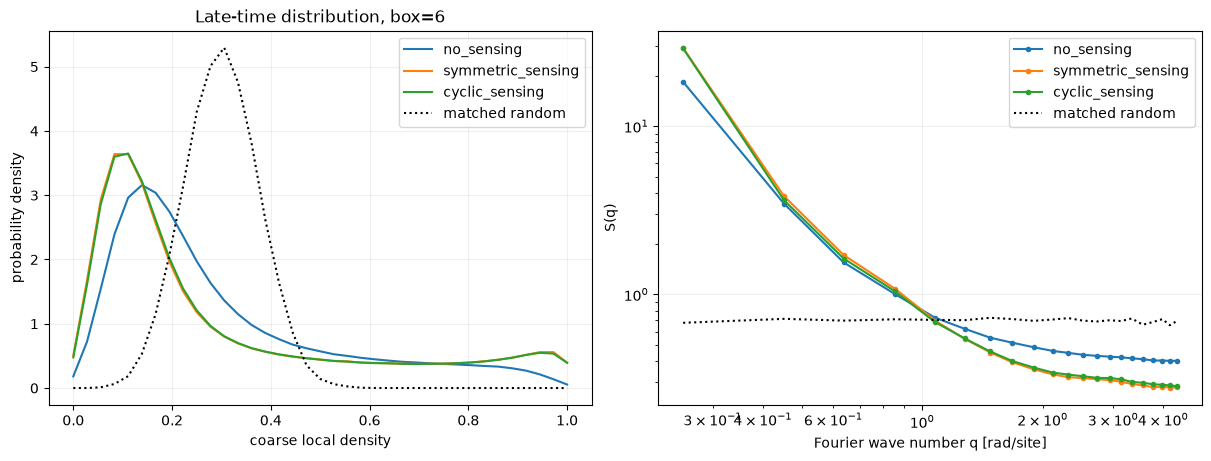

In [36]:
# Align bins with the discrete occupied count in each coarse window.
# Arbitrary bin widths create artificial alternating peaks for m / box**2.
window_sites = COARSE_BOX**2
hist_edges = (np.arange(window_sites + 2) - 0.5) / window_sites
hist_centers = (hist_edges[:-1] + hist_edges[1:]) / 2
q_axis = 2 * np.pi * np.fft.fftfreq(physics.lattice_size)
qy, qx = np.meshgrid(q_axis, q_axis, indexing="ij")
q_radius = np.hypot(qx, qy)
q_bin = np.rint(q_radius / (2 * np.pi / physics.lattice_size)).astype(int)
q_nonzero = q_radius > 0
bin_counts = np.bincount(q_bin[q_nonzero])
valid_bins = bin_counts > 0
q_centers = (np.bincount(q_bin[q_nonzero], weights=q_radius[q_nonzero])[valid_bins]
             / bin_counts[valid_bins])

def radial_structure(occupied):
    occupied = occupied.astype(np.float64)
    power = np.abs(np.fft.fft2(occupied - occupied.mean()))**2 / occupied.sum()
    return np.bincount(q_bin[q_nonzero], weights=power[q_nonzero])[valid_bins] / bin_counts[valid_bins]

def density_histogram(occupied):
    density_field = coarse_density_periodic(occupied, box=COARSE_BOX)
    return np.histogram(density_field, bins=hist_edges, density=True)[0]

histograms, spectra = {}, {}
for name, result in results.items():
    histograms[name] = np.stack([
        np.mean([density_histogram(result.states[replica, frame] >= 0) for frame in late_frames], axis=0)
        for replica in range(ENSEMBLE_SIZE)
    ])
    spectra[name] = np.stack([
        np.mean([radial_structure(result.states[replica, frame] >= 0) for frame in late_frames], axis=0)
        for replica in range(ENSEMBLE_SIZE)
    ])
    np.testing.assert_allclose((histograms[name] * np.diff(hist_edges)).sum(axis=1), 1.0)
random_histogram = np.mean([density_histogram(state) for state in random_states], axis=0)
random_spectrum = np.mean([radial_structure(state) for state in random_states], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for name in results:
    mean = histograms[name].mean(axis=0)
    sem = histograms[name].std(axis=0, ddof=1) / np.sqrt(ENSEMBLE_SIZE)
    axes[0].plot(hist_centers, mean, label=name)
    axes[0].fill_between(hist_centers, np.maximum(0, mean-sem), mean+sem, alpha=0.2)
    mean = spectra[name].mean(axis=0)
    sem = spectra[name].std(axis=0, ddof=1) / np.sqrt(ENSEMBLE_SIZE)
    axes[1].plot(q_centers, mean, ".-", label=name)
    axes[1].fill_between(q_centers, np.maximum(mean-sem, 1e-12), np.maximum(mean+sem, 1e-12), alpha=0.2)
axes[0].plot(hist_centers, random_histogram, "k:", label="matched random")
axes[1].plot(q_centers, random_spectrum, "k:", label="matched random")
axes[0].set(xlabel="coarse local density", ylabel="probability density",
            title=f"Late-time distribution, box={COARSE_BOX}")
axes[1].set(xlabel="Fourier wave number q [rad/site]", ylabel="S(q)", xscale="log", yscale="log")
for ax in axes:
    ax.legend(); ax.grid(alpha=0.2)
fig.savefig(RESULT_DIR / "density_distribution_and_structure_factor.png", dpi=160)
plt.show()

In [37]:
if SHOW_ANIMATION:
    selected = np.unique(np.linspace(0, N_FRAMES - 1, min(MAX_ANIMATION_FRAMES, N_FRAMES), dtype=int))
    cmap = ListedColormap(["white", "#377eb8", "#e41a1c", "#4daf4a", "#984ea3"])
    fig, axes = plt.subplots(1, len(results), figsize=(4.5 * len(results), 4), squeeze=False, constrained_layout=True)
    axes = axes.ravel()
    artists = []
    for ax, (name, result) in zip(axes, results.items()):
        artists.append(ax.imshow(result.states[0, 0] + 1, cmap=cmap, vmin=-0.5, vmax=4.5))
        ax.set_xticks([]); ax.set_yticks([])
    def update_animation(index):
        frame = selected[index]
        for ax, artist, (name, result) in zip(axes, artists, results.items()):
            artist.set_data(result.states[0, frame] + 1)
            ax.set_title(f"{name}, t={times[frame]:g}")
        return artists
    animation = FuncAnimation(fig, update_animation, frames=len(selected), interval=120)
    plt.close(fig)
    html = animation.to_jshtml()
    (RESULT_DIR / "mips_animation.html").write_text(html, encoding="utf-8")
    display(HTML(html))
else:
    print("Animation disabled (set SHOW_ANIMATION=True to inspect dynamics).")


## Sensing-count and speed distributions

Sample actual occupied sites in the late fixed-time snapshots. A fixed sum of angular weights does not fix the variance of \(q\): concentrating the weight on one heading changes its statistics and, through saturation, the speed distribution. These are particle-and-time sampled diagnostics; uncertainty uses per-replica means. The plotted forward rate is the **unblocked** rate, so exclusion may lower the realized hopping rate.

Changing \(\chi\) can make nonsymmetric direction-channel shell features useful to ShellForce. This notebook checks the resulting dynamics, not NN learning. Use the matched control runs, validation objectives, and branch-drop diagnostics in `Corr_labpks.ipynb` to test whether the trained model actually uses those outer features.


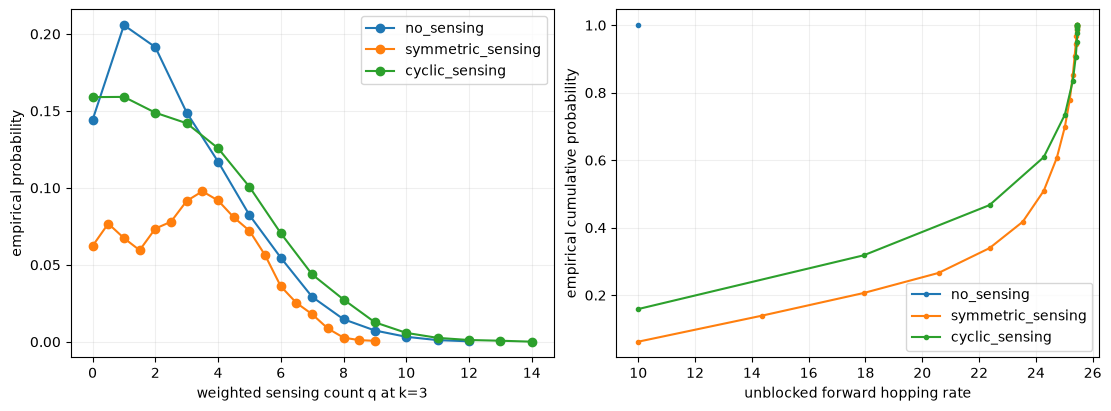

{
  "no_sensing": {
    "angular_bias": 1.0,
    "shells": [
      2,
      3,
      4
    ],
    "weighted_count_mean": [
      1.9602623456790123,
      2.678395061728395,
      3.2916666666666665
    ],
    "weighted_count_std": [
      1.7619200540472217,
      2.1204026270303276,
      2.318629264601568
    ],
    "weighted_count_zero_fraction": [
      0.23657407407407408,
      0.1441358024691358,
      0.09074074074074075
    ],
    "unblocked_forward_rate_mean": 10.0,
    "unblocked_forward_rate_replica_sem": 0.0,
    "unblocked_forward_rate_quantiles": [
      10.0,
      10.0,
      10.0,
      10.0
    ]
  },
  "symmetric_sensing": {
    "angular_bias": 0.0,
    "shells": [
      2,
      3,
      4
    ],
    "weighted_count_mean": [
      2.35516975308642,
      3.1617283950617283,
      3.8155092592592594
    ],
    "weighted_count_std": [
      1.4741510851337971,
      1.9146832991667364,
      2.1083842520364873
    ],
    "weighted_count_zero_fraction": [
      0.090

In [38]:
def sensing_values(state, case_config):
    occupied = state >= 0
    directions = state[occupied].astype(np.int64)
    contributions = np.zeros((len(directions), len(case_config.shell_weights)), dtype=np.float64)
    weighted_counts = np.zeros_like(contributions)
    plus = (1 + case_config.angular_bias) / 2
    minus = (1 - case_config.angular_bias) / 2
    for shell_index, beta in enumerate(case_config.shell_weights):
        k = shell_index + 2
        counts = np.zeros((4, *state.shape), dtype=np.float64)
        for dr in range(-k, k + 1):
            for dc in range(-k, k + 1):
                if max(abs(dr), abs(dc)) != k:
                    continue
                neighbor = np.roll(state, shift=(-dr, -dc), axis=(0, 1))
                for c in range(4):
                    counts[c] += plus * (neighbor == (c + 1) % 4) + minus * (neighbor == (c - 1) % 4)
        q = counts[:, occupied][directions, np.arange(len(directions))]
        weighted_counts[:, shell_index] = q
        contributions[:, shell_index] = beta * (-np.expm1(-q / case_config.sensing_scale))
    forward = case_config.backward_rate + (case_config.forward_rate - case_config.backward_rate) * np.exp(contributions.sum(axis=1))
    return weighted_counts, forward

sensing_statistics = {}
sensing_plot_values = {}
selected_late = late_frames[np.unique(np.linspace(0, len(late_frames) - 1, min(12, len(late_frames)), dtype=int))]
for name, case_config in cases.items():
    replica_counts, replica_rates = [], []
    for replica in range(ENSEMBLE_SIZE):
        values = [sensing_values(results[name].states[replica, frame], case_config) for frame in selected_late]
        replica_counts.append(np.concatenate([item[0] for item in values]))
        replica_rates.append(np.concatenate([item[1] for item in values]))
    all_counts = np.concatenate(replica_counts)
    all_rates = np.concatenate(replica_rates)
    replica_mean_rates = np.array([rates.mean() for rates in replica_rates])
    sensing_statistics[name] = {
        "angular_bias": case_config.angular_bias,
        "shells": list(range(2, len(case_config.shell_weights) + 2)),
        "weighted_count_mean": all_counts.mean(axis=0).tolist(),
        "weighted_count_std": all_counts.std(axis=0).tolist(),
        "weighted_count_zero_fraction": (all_counts == 0).mean(axis=0).tolist(),
        "unblocked_forward_rate_mean": float(replica_mean_rates.mean()),
        "unblocked_forward_rate_replica_sem": float(replica_mean_rates.std(ddof=1) / np.sqrt(ENSEMBLE_SIZE)),
        "unblocked_forward_rate_quantiles": np.quantile(all_rates, [0, .5, .9, 1]).tolist(),
    }
    sensing_plot_values[name] = (all_counts, all_rates)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
active = next((i for i, beta in enumerate(physics.shell_weights) if beta > 0), 0)
for name, (counts, rates) in sensing_plot_values.items():
    count_values, frequency = np.unique(counts[:, active], return_counts=True)
    axes[0].plot(count_values, frequency / frequency.sum(), "o-", label=name)
    rate_values, frequency = np.unique(rates, return_counts=True)
    axes[1].plot(rate_values, np.cumsum(frequency) / frequency.sum(), ".-", label=name)
axes[0].set(xlabel=f"weighted sensing count q at k={active + 2}", ylabel="empirical probability")
axes[1].set(xlabel="unblocked forward hopping rate", ylabel="empirical cumulative probability")
for ax in axes:
    ax.legend(); ax.grid(alpha=.2)
fig.savefig(RESULT_DIR / "sensing_and_speed_statistics.png", dpi=160)
plt.show()
print(json.dumps(sensing_statistics, indent=2))


## Save diagnostics and inspect late-time drift

The table reports means and standard errors of **per-replica late-time averages**. A late-half difference checks whether relaxation is still evident; it is a diagnostic, not a stationarity test. No automatic MIPS pass/fail threshold is imposed.

If domains keep growing, extend the simulation. If a spanning cluster also appears in the matched random reference, use the density distribution and low-q signal to separate connectivity from coexistence. Compare larger systems and additional density points before interpreting a finite box as macroscopic phase separation.

In [39]:
late_mask = diagnostic_frames >= late_frames[0]
summary = {
    "physics": {name: asdict(config) for name, config in cases.items()},
    "sampling": {"sample_dt": SAMPLE_DT, "sampling_frequency": 1 / SAMPLE_DT,
                 "observation_time": OBSERVATION_TIME, "burn_time": BURN_TIME, "n_frames": N_FRAMES},
    "ensemble_size": ENSEMBLE_SIZE, "seed": SEED, "workers": WORKERS,
    "backend_request": SIMULATION_BACKEND, "backend": RESOLVED_SIMULATION_BACKEND,
    "cuda_batch_size": CUDA_BATCH_SIZE,
    "coarse_box": COARSE_BOX, "diagnostic_stride": DIAGNOSTIC_STRIDE,
    "late_fraction": LATE_FRACTION, "smoke": SMOKE,
    "interpretation": "Screening diagnostics only; finite-box clustering is not a proof of MIPS.",
    "cases": {},
    "sensing_statistics": sensing_statistics,
    "angular_comparison_note": "Fixed angular-weight sum does not fix sensing-count variance or mean saturated forward speed.",
}
arrays = {"times": times, "diagnostic_frames": diagnostic_frames, "late_frames": late_frames,
          "hist_edges": hist_edges, "q": q_centers, "random_metrics": random_metrics,
          "random_histogram": random_histogram, "random_spectrum": random_spectrum}
for name, metrics in diagnostics.items():
    replica_late = metrics[:, late_mask].mean(axis=1)
    late_metrics = metrics[:, late_mask]
    split = max(1, late_metrics.shape[1] // 2)
    drift = (late_metrics[:, split:].mean(axis=1) - late_metrics[:, :split].mean(axis=1)
             if split < late_metrics.shape[1] else np.zeros_like(replica_late))
    summary["cases"][name] = {
        key: {"mean": float(replica_late[:, component].mean()),
              "sem": float(replica_late[:, component].std(ddof=1) / np.sqrt(ENSEMBLE_SIZE)),
              "late_half_change_mean": float(drift[:, component].mean())}
        for component, key in enumerate(metric_keys)
    }
    summary["cases"][name]["replica_seeds"] = results[name].seeds.tolist()
    arrays[f"{name}_metrics"] = metrics
    arrays[f"{name}_histograms"] = histograms[name]
    arrays[f"{name}_spectra"] = spectra[name]
    arrays[f"{name}_snapshots"] = results[name].states[:, snapshot_frames]
summary["simulator_sha256"] = hashlib.sha256(
    b"".join(p.read_bytes() for p in sorted((ROOT / "data" / "labp_ks").glob("*.py")))
).hexdigest()
cuda_source_path = ROOT / "data" / "labp_ks" / "_gillespie_cuda.py"
summary["cuda_source_sha256"] = hashlib.sha256(cuda_source_path.read_bytes()).hexdigest() if cuda_source_path.is_file() else None
(RESULT_DIR / "summary.json").write_text(json.dumps(summary, indent=2, allow_nan=False), encoding="utf-8")
np.savez_compressed(RESULT_DIR / "mips_diagnostics.npz", **arrays)
print(json.dumps(summary["cases"], indent=2))
print("Saved figures and diagnostics:", RESULT_DIR)
print("Smoke complete." if SMOKE else "Inspect the plots and late-time drift before interpreting clustering as MIPS.")
plt.close("all")


{
  "no_sensing": {
    "largest_cluster_fraction": {
      "mean": 0.5408683908683904,
      "sem": 0.0049590378831571216,
      "late_half_change_mean": 0.011525267982553572
    },
    "coarse_std": {
      "mean": 0.2259950798393601,
      "sem": 0.000809912367922507,
      "late_half_change_mean": 0.002186621099318574
    },
    "density_contrast": {
      "mean": 0.5911414973914965,
      "sem": 0.002386821376222012,
      "late_half_change_mean": 0.007236876247505769
    },
    "low_k_ratio": {
      "mean": 10.371853444139969,
      "sem": 0.06820613272375516,
      "late_half_change_mean": 0.2644636250947827
    },
    "replica_seeds": [
      1239039659,
      3860685347,
      3567137017,
      2107282838
    ]
  },
  "symmetric_sensing": {
    "largest_cluster_fraction": {
      "mean": 0.7272237022237021,
      "sem": 0.0007915808574144979,
      "late_half_change_mean": -0.0009220447992901171
    },
    "coarse_std": {
      "mean": 0.2767828793725728,
      "sem": 0.00040

## Exact inter-event waiting-time distribution

Continue each case's final snapshots with a short **CPU exact Gillespie** diagnostic. Record complete intervals between consecutive **whole-system events (hops + rotations)**, not frame spacings or single-particle waiting times. Discard the first delay from each snapshot because it starts at an arbitrary observation time.

Each replica supplies up to `WAITING_EVENTS_PER_REPLICA` complete intervals. This is an equal-replica mixture of event-sampled traces, not a time-weighted state distribution. The original trajectories and sampling interval remain unchanged. Empty traces indicate no complete intervals before absorption.

The total rate `a` changes with configuration, so pooled physical waits can form a mixture of exponentials. The single exponential with the same mean is only a comparison. Rescaled waits `z = a * tau` should have the unit exponential survival function `exp(-z)`, providing a conditional Gillespie clock check.


In [40]:
from data.labp_ks.waiting_times import sample_waiting_times

WAITING_EVENTS_PER_REPLICA = 256 if SMOKE else 20000
WAITING_SEED = SEED + 47031
waiting_arrays, waiting_summary = {}, {}
for name, case_config in cases.items():
    traces = sample_waiting_times(
        case_config, results[name].states[:, -1],
        n_events=WAITING_EVENTS_PER_REPLICA, seed=WAITING_SEED, workers=WORKERS,
    )
    waits = np.concatenate([trace["waiting_times"] for trace in traces])
    rates = np.concatenate([trace["escape_rates"] for trace in traces])
    sizes = np.array([len(trace["waiting_times"]) for trace in traces], dtype=np.int64)
    waiting_arrays[f"{name}_waiting_times"] = waits
    waiting_arrays[f"{name}_escape_rates"] = rates
    waiting_arrays[f"{name}_event_types"] = np.concatenate([trace["event_types"] for trace in traces])
    waiting_arrays[f"{name}_replica_offsets"] = np.r_[0, np.cumsum(sizes)]
    waiting_summary[name] = {
        "physics": asdict(case_config),
        "start_physical_time": float(BURN_TIME + results[name].times[-1]),
        "replica_seeds": [trace["seed"] for trace in traces],
        "complete_intervals_per_replica": sizes.tolist(),
        "replicas_without_complete_intervals": int(np.sum(sizes == 0)),
        "replicas_stopped_before_event_limit": int(np.sum(sizes < WAITING_EVENTS_PER_REPLICA)),
        "mean_wait": float(waits.mean()) if len(waits) else None,
        "wait_quantiles_0_50_90_99_100": np.quantile(waits, [0, .5, .9, .99, 1]).tolist() if len(waits) else [],
        "mean_rescaled_wait": float((waits * rates).mean()) if len(waits) else None,
        "zero_wait_count": int(np.sum(waits == 0)),
    }

positive = np.concatenate([
    waiting_arrays[f"{name}_waiting_times"][waiting_arrays[f"{name}_waiting_times"] > 0]
    for name in cases
])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
if len(positive):
    low, high = float(positive.min()), float(positive.max())
    bins = np.geomspace(low * .9, max(high * 1.1, low * 1.2), 65)
    for name in cases:
        waits = waiting_arrays[f"{name}_waiting_times"]
        if not len(waits):
            continue
        density, _ = np.histogram(waits[waits > 0], bins=bins, density=False)
        density = density / len(waits) / np.diff(bins)
        line = axes[0].stairs(density, bins, label=name)
        color = line.get_edgecolor()
        ordered = np.sort(waits)
        survival = (len(ordered) - np.arange(1, len(ordered) + 1)) / len(ordered)
        axes[1].plot(ordered[survival > 0], survival[survival > 0], color=color, label=name)
        if waits.mean() > 0:
            grid = np.geomspace(bins[0], bins[-1], 400)
            axes[1].plot(grid, np.exp(-grid / waits.mean()), "--", color=color,
                         alpha=.7, label=f"{name}: exponential with same mean")
        scaled = np.sort(waits * waiting_arrays[f"{name}_escape_rates"])
        axes[2].plot(scaled[survival > 0], survival[survival > 0], label=name)
    z = np.linspace(0, 10, 400)
    axes[2].plot(z, np.exp(-z), "k--", label="Exp(1) reference")
else:
    for ax in axes:
        ax.text(.5, .5, "No positive complete waiting intervals", ha="center", transform=ax.transAxes)
axes[0].set(xscale="log", yscale="log", xlabel="inter-event waiting time tau",
            ylabel="probability density", title="Physical waiting times")
axes[1].set(xscale="log", yscale="log", xlabel="inter-event waiting time tau",
            ylabel="P(wait > tau)", title="Survival / exponential comparison", ylim=(1e-5, 1.05))
axes[2].set(yscale="log", xlabel="z = total pre-event rate * tau",
            ylabel="P(rescaled wait > z)", title="Conditional-clock check",
            xlim=(0, 10), ylim=(1e-5, 1.05))
for ax in axes:
    ax.grid(alpha=.2)
    if ax.get_legend_handles_labels()[0]:
        ax.legend(fontsize=8)
fig.savefig(RESULT_DIR / "waiting_time_distribution.png", dpi=160)
plt.show()
plt.close(fig)
np.savez_compressed(RESULT_DIR / "waiting_time_samples.npz", **waiting_arrays)
waiting_metadata = {
    "backend": "cpu", "event_definition": "all system hops plus rotations",
    "first_snapshot_delay_discarded": True,
    "requested_intervals_per_replica": WAITING_EVENTS_PER_REPLICA,
    "simulator_sha256": hashlib.sha256(b"".join(p.read_bytes() for p in sorted((ROOT / "data" / "labp_ks").glob("*.py")))).hexdigest(),
    "cases": waiting_summary,
}
(RESULT_DIR / "waiting_time_summary.json").write_text(
    json.dumps(waiting_metadata, indent=2, allow_nan=False), encoding="utf-8",
)
print(json.dumps(waiting_summary, indent=2))
print("Saved waiting-time figure, event samples and summary:", RESULT_DIR)


ModuleNotFoundError: No module named 'data.labp_ks.waiting_times'